In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline



In [90]:
path = '/Users/pawanadhikari/Documents/Roadmap/Python/AL/Insurance_Regression/insurance.csv'
data = pd.read_csv(path)
data.head()
test_data = pd.read_csv(path)

In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [92]:
data.values

array([[19, 'female', 27.9, ..., 'yes', 'southwest', 16884.924],
       [18, 'male', 33.77, ..., 'no', 'southeast', 1725.5523],
       [28, 'male', 33.0, ..., 'no', 'southeast', 4449.462],
       ...,
       [18, 'female', 36.85, ..., 'no', 'southeast', 1629.8335],
       [21, 'female', 25.8, ..., 'no', 'southwest', 2007.945],
       [61, 'female', 29.07, ..., 'yes', 'northwest', 29141.3603]],
      dtype=object)

In [93]:
data.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [94]:
data.value_counts

<bound method DataFrame.value_counts of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [95]:
data.axes

[RangeIndex(start=0, stop=1338, step=1),
 Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')]

In [96]:
data.index

RangeIndex(start=0, stop=1338, step=1)

In [97]:
data['Male'] = 0
print(type(data.iloc[:,1]))
for i in data.iloc[:,1]:
    print (i)

<class 'pandas.core.series.Series'>
female
male
male
male
male
female
female
female
male
female
male
female
male
female
male
male
female
male
male
male
female
female
male
female
male
female
female
female
male
male
male
female
female
male
male
male
female
male
male
male
female
female
male
female
male
male
female
female
female
male
female
female
male
male
female
male
female
male
female
female
male
male
male
female
female
female
female
male
female
male
female
male
female
male
male
male
female
male
female
female
male
female
male
female
female
male
female
female
female
female
female
female
male
male
female
female
female
male
male
male
female
male
female
female
female
male
female
male
male
male
male
female
male
female
male
male
male
female
female
female
male
male
female
male
female
female
female
female
female
male
female
female
female
male
female
female
male
male
female
female
male
male
male
male
male
female
male
female
female
male
male
male
female
female
female
male
male
male
male
female
fe

In [98]:
data['isSmoker'] = 0
data['isSW'] = 0
data['isNW'] = 0
data['isSE'] = 0
data['isNE'] = 0
data['isMale'] = 0
data['isFemale'] = 0

data.loc[data['smoker']=='yes','isSmoker'] = 1
data.loc[data['region']=='southwest','isSW'] = 1
data.loc[data['region']=='southeast','isSE'] = 1
data.loc[data['region']=='northwest','isNW'] = 1
data.loc[data['region']=='northeast','isNE'] = 1
data.loc[data['sex']=='male','isMale'] = 1
data.loc[data['sex']=='female','isFemale'] = 1

data.head()

,age,sex,bmi,children,smoker,region,charges,Male,isSmoker,isSW,isNW,isSE,isNE,isMale,isFemale
0,19,female,27.900,0,yes,southwest,16884.92400,0,1,1,0,0,0,0,1
1,18,male,33.770,1,no,southeast,1725.55230,0,0,0,0,1,0,1,0
2,28,male,33.000,3,no,southeast,4449.46200,0,0,0,0,1,0,1,0
3,33,male,22.705,0,no,northwest,21984.47061,0,0,0,1,0,0,1,0
4,32,male,28.880,0,no,northwest,3866.85520,0,0,0,1,0,0,1,0


In [99]:
#Deleting unwanted Columns
data.drop(['sex','smoker','region','isFemale','isNE'], axis='columns', inplace=True)
data.head()

,age,bmi,children,charges,Male,isSmoker,isSW,isNW,isSE,isMale
0,19,27.900,0,16884.92400,0,1,1,0,0,0
1,18,33.770,1,1725.55230,0,0,0,0,1,1
2,28,33.000,3,4449.46200,0,0,0,0,1,1
3,33,22.705,0,21984.47061,0,0,0,1,0,1
4,32,28.880,0,3866.85520,0,0,0,1,0,1


In [100]:
test_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [101]:
test_data_processed = pd.get_dummies(test_data, columns = ['sex', 'smoker', 'region'], drop_first=True)
test_data_processed.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Test_data or data, either way, we now have processed data. Now, we need to separate the features(Independent variables) and target(Dependent variables) as X and Y. 

In [102]:
X = data.drop('charges', axis = 1)
X.head()

,age,bmi,children,Male,isSmoker,isSW,isNW,isSE,isMale
0,19,27.900,0,0,1,1,0,0,0
1,18,33.770,1,0,0,0,0,1,1
2,28,33.000,3,0,0,0,0,1,1
3,33,22.705,0,0,0,0,1,0,1
4,32,28.880,0,0,0,0,1,0,1


In [103]:
Y = data['charges']
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [104]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.20, random_state=42)

In [105]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


We will now have to create a regression model to train our data on.

In [106]:
regr = linear_model.LinearRegression()

Then simply train the model on our dataset.

In [107]:
pipeline = Pipeline([
                    ("poly", poly),
                    ("model", regr)
                    ])

scores = cross_val_score(
    pipeline,
    X,
    Y,
    cv = 10,
    scoring = "neg_mean_squared_error"
)
positive_mse_scores = -scores
rmse_scores = np.sqrt(positive_mse_scores)
regr.fit(X_train_poly, Y_train)

LinearRegression()

Then simlpy run our validation/test set on it!

In [108]:
Y_predicted = regr.predict(X_test_poly)

Now, Plot the results and also show some key statistics.

In [109]:
print(type(Y_test))
type(Y_predicted)

<class 'pandas.core.series.Series'>


numpy.ndarray

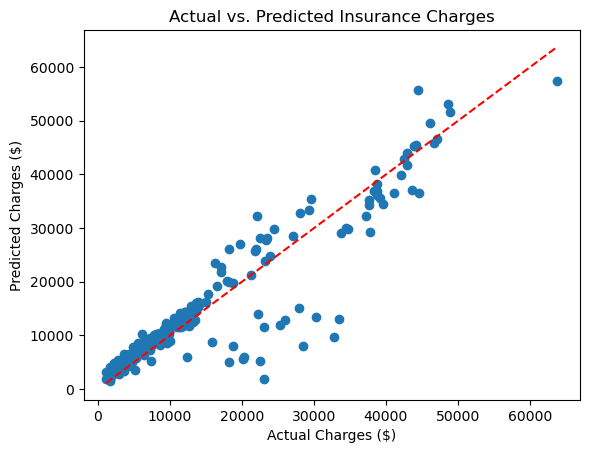

Root mean squared error(This run):  4551.1323852332025
R2 score: (This run) 0.8500064367014838
Cross validation RMSE, Polynomial Regression:  4841.274732799411


In [110]:
plt.scatter(Y_test,Y_predicted)
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs. Predicted Insurance Charges")
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--')
plt.show()
print("Root mean squared error(This run): ", mean_squared_error(Y_predicted, Y_test) ** 0.5)
print("R2 score: (This run)", r2_score(Y_predicted, Y_test))
sum = 0.0
for i in rmse_scores:
    sum = sum + i
rmse = sum/10
print("Cross validation RMSE, Polynomial Regression: ", rmse)